In [1]:
!pip3 install pandas keras tensorflow scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [5]:
# Load the dataset CSV file
# Format: 
#   filename - original stl file name, for tracking
#   d - distance to object in mm
#   o - distance between cameras in mm
#   rx, ry, rz - rotation angles in degrees
#   left - path to left image
#  right - path to right image
dataset_file = './stl_data/base_permuted_output/256x256/base_permuted.csv'

# Set the image size for loading images & building the neural network model
image_size = (256, 256)

X (merged L+R stereo images) shape: (134, 256, 256, 2)
y (distance d) shape: (134,)


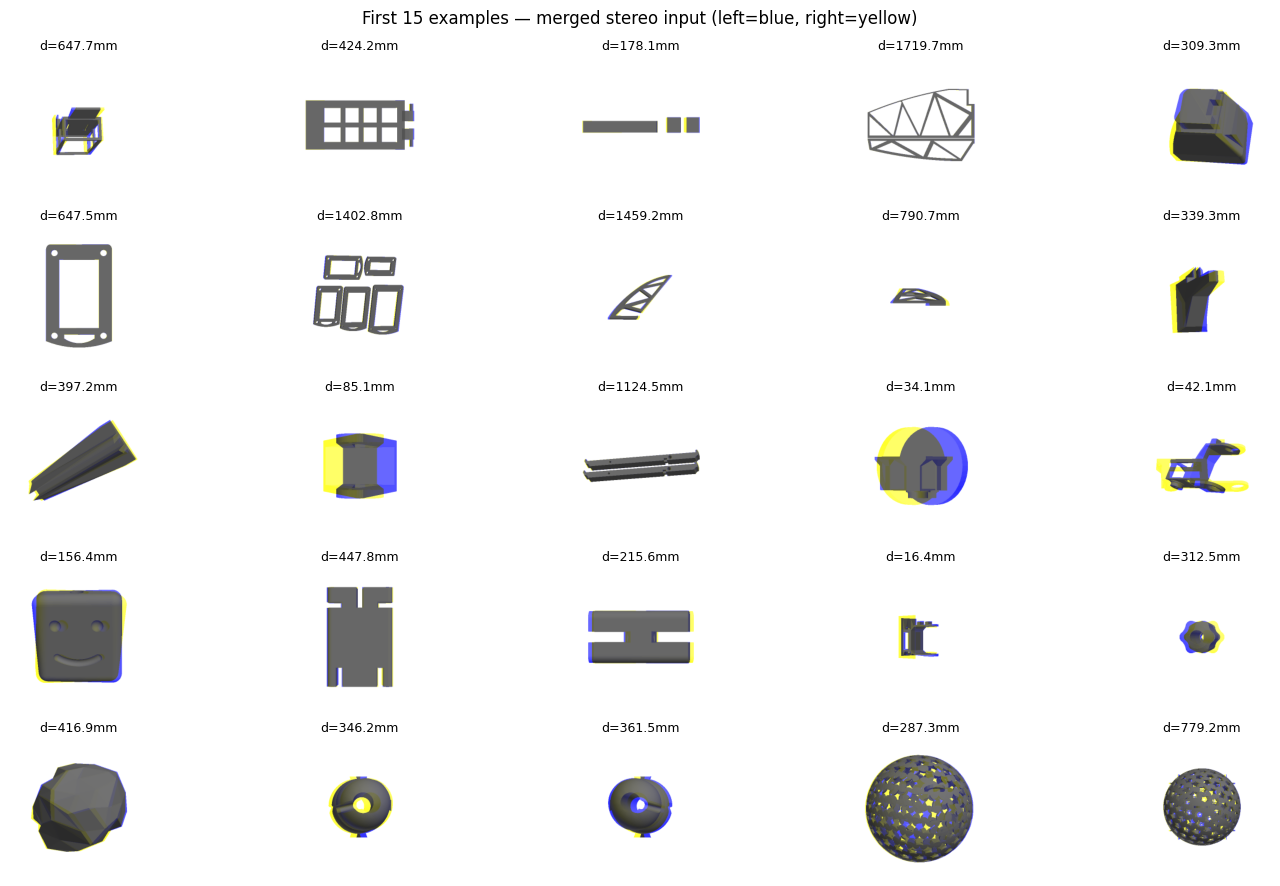

In [6]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
df = pd.read_csv(dataset_file)
dataset_path = os.path.dirname(dataset_file)

# The source renders are single-channel grayscale (mode "L"), not RGB.
# Merge each stereo pair into one 2-channel image: channel 0 = left, channel 1 = right.
# This is early fusion (approach B): the network sees L and R as two dimensions of
# ONE input, the same way an RGB image's 3 channels are treated as one input.
left_imgs, right_imgs, d_values = [], [], []
missing_files = []

for _, row in df.iterrows():
    left_path = os.path.join(dataset_path, row["left"])
    right_path = os.path.join(dataset_path, row["right"])

    if not os.path.exists(left_path) or not os.path.exists(right_path):
        missing_files.append((left_path, right_path))
        continue

    left_imgs.append(np.asarray(Image.open(left_path).convert("L")))
    right_imgs.append(np.asarray(Image.open(right_path).convert("L")))
    d_values.append(row["d"])

if missing_files:
    print(f"{len(missing_files)} missing image files for some rows:", missing_files)
    raise FileNotFoundError("Dataset is corrupt; Some image files are missing. Please check the paths.")

X = np.stack([np.stack([l, r], axis=-1) for l, r in zip(left_imgs, right_imgs)])
y = np.array(d_values, dtype="float32")

print(f"X (merged L+R stereo images) shape: {X.shape}")
print(f"y (distance d) shape: {y.shape}")

# Visualize the first 25 examples. The 2-channel data isn't directly viewable as an
# image, so for display only: left channel -> blue, right channel -> yellow.
n_show = 25
fig, axes = plt.subplots(5, 5, figsize=(15, 9))
for i, ax in enumerate(axes.flat[:n_show]):
    left_norm = X[i, :, :, 0].astype("float32") / 255.0
    right_norm = X[i, :, :, 1].astype("float32") / 255.0
    vis = np.stack([right_norm, right_norm, left_norm], axis=-1)  # yellow = R+G, blue = B
    ax.imshow(vis)
    ax.set_title(f"d={y[i]:.1f}mm", fontsize=9)
    ax.axis("off")
plt.suptitle("First 15 examples — merged stereo input (left=blue, right=yellow)")
plt.tight_layout()
plt.show()

In [7]:
# Build the neural network model, and output the model summary

import tensorflow as tf

input_shape = image_size + (2,)

def model_tree(input_tensor):
    x = tf.keras.layers.Conv2D(32, 5, activation="relu", padding="same")(input_tensor)
    x = tf.keras.layers.MaxPool2D(2)(x)
    x = tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPool2D(2)(x)
    x = tf.keras.layers.Flatten()(x) 
    x = tf.keras.layers.Dense(32, activation="relu")(x)
    x = tf.keras.layers.Dense(1, activation="linear", name = "d")(x)
    return x

input_image = tf.keras.Input(shape=input_shape, name="image_stereo")
output_d = model_tree(input_image)

model = tf.keras.Model(inputs=input_image, outputs=output_d)
model.compile(optimizer="adam", loss="mse", )

model.summary()

/Users/nivnoach/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_stereo (InputLayer)       │ (None, 256, 256, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     2,097,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d (Dense)                       │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,103,473 (8.02 MB)

 Trainable params: 2,103,473 (8.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# normalize image data for training
adjusted_images = X.astype("float32") / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    adjusted_images, y, test_size=0.2, random_state=42, shuffle=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=60,
    batch_size=20,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

NameError: name 'Stereo_Images' is not defined

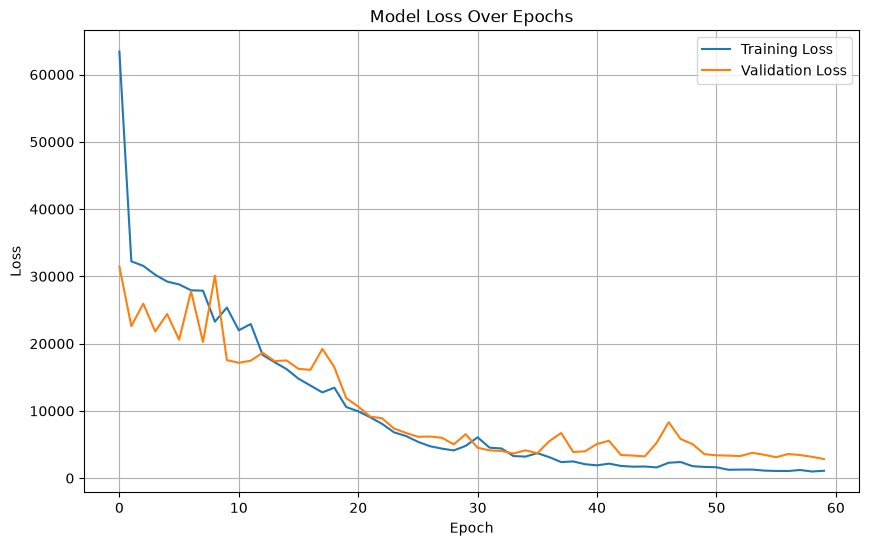

In [30]:
# Plot the training and validation loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


/Users/hanandann/Developer/Antigravity/Paralex Generator/stereo_crunch/.venv-tools/lib/python3.13/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: image_stereo
Received: inputs=('Tensor(shape=(32, 256, 256, 2))',)
  warnings.warn(msg)
/Users/hanandann/Developer/Antigravity/Paralex Generator/stereo_crunch/.venv-tools/lib/python3.13/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: image_stereo
Received: inputs=('Tensor(shape=(None, 256, 256, 2))',)
  warnings.warn(msg)


Test accuracy: 0.0000
Test weighted F1 score: 0.0000
Confusion matrix:


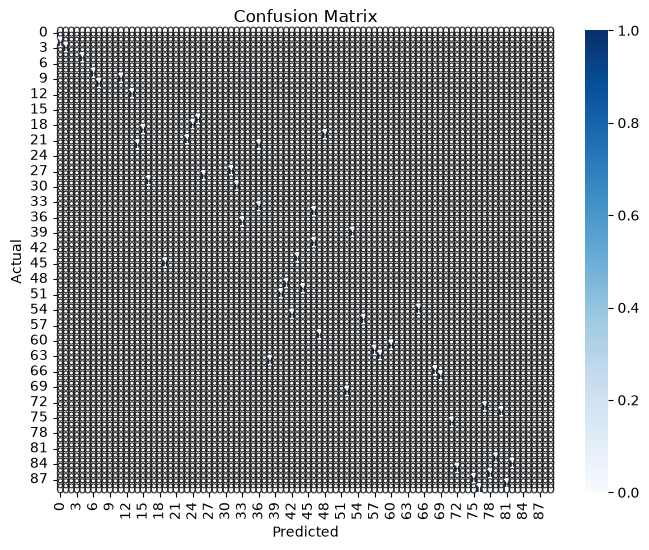

In [34]:
# Evaluate the model on the test set and print accuracy, F1 score, and confusion matrix
# 
# Confusion matrix and F1 score are more meaningful for classification tasks, but since
# this is a regression task, we will convert the continuous outputs to discrete labels
# for evaluation purposes.

import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict([X_test]).flatten()

# convert regression outputs to discrete labels for accuracy / f1 / confusion matrix
y_test_cls = np.rint(y_test).astype(int)
y_pred_cls = np.rint(y_pred).astype(int)

acc = accuracy_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls, average="weighted")
cm = confusion_matrix(y_test_cls, y_pred_cls)

print(f"Test accuracy: {acc:.4f}")
print(f"Test weighted F1 score: {f1:.4f}")
print("Confusion matrix:")

# Display the confusion matrix as a heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()